In [ ]:
from adapter import System
from optimizer import Optimizer
path_to_system_json = "./models/complete_model.json"

system = System(model_path=path_to_system_json)

In [ ]:
system.plot_assembly()

In [2]:
optimizer = Optimizer(system=system, num_generations=300, num_populations=10, verbose=True)

In [3]:
optimizer.run()

Starting optimization of 'Drivetrain System Template - Small-Scale Testbench'...
n_gen  |  n_eval  |     f_avg     |     f_min    
     1 |       10 |  4.000000E+11 |  1.510400E+02
     2 |       20 |  1.475615E+02 |  1.510400E+02
     3 |       30 |  1.454974E+02 |  1.374033E+02
     4 |       40 |  1.453466E+02 |  1.374032E+02
     5 |       50 |  1.453486E+02 |  1.513918E+02
     6 |       60 |  1.453282E+02 |  1.513918E+02
     7 |       70 |  1.450849E+02 |  1.515047E+02
     8 |       80 |  1.450849E+02 |  1.515047E+02
     9 |       90 |  1.450849E+02 |  1.374032E+02
    10 |      100 |  1.450849E+02 |  1.374032E+02
    11 |      110 |  1.450849E+02 |  1.374032E+02
    12 |      120 |  1.450849E+02 |  1.374032E+02
    13 |      130 |  1.450845E+02 |  1.515047E+02
    14 |      140 |  1.450845E+02 |  1.515047E+02
    15 |      150 |  1.433638E+02 |  1.515047E+02
    16 |      160 |  1.441542E+02 |  1.515047E+02
    17 |      170 |  1.441540E+02 |  1.367123E+02
    18 |      180 |

In [54]:
final_results = optimizer.final_results
I_total, T_vib_max = [], []

for candidate in final_results:
    I_total.append(candidate["results"]["objectives"][1])
    T_vib_max.append(candidate["results"]["objectives"][0])

In [113]:
final_results = optimizer.final_results
damp_prop, d_2, l_2, mat_2, coup= [],[],[],[],[]
P_loss_max_ss, T_vib_max_ss = [], []
P_loss_max, T_vib_max = [], []

for candidate in final_results:
    coup.append(candidate["design_vars"]["Coupling<<>>Choice"])
    damp_prop.append(candidate["design_vars"]["Propeller<<>>torsionalDamping"])
    d_2.append(candidate["design_vars"]["Propeller_Shaft<<>>diameter"])
    l_2.append(candidate["design_vars"]["Propeller_Shaft<<>>length"])
    mat_2.append(candidate["design_vars"]["Propeller_Shaft<<>>Choice"])
    P_loss_max_ss.append(candidate["results"]["max_P_loss_ss"])
    T_vib_max_ss.append(candidate["results"]["max_Tvib_ss"])
    P_loss_max.append(candidate["results"]["max_P_loss"])
    T_vib_max.append(candidate["results"]["max_Tvib"])


import numpy as np

mask = np.array(T_vib_max_ss) < 1e12

(
    coup,
    damp_prop,
    d_2,
    l_2,
    mat_2,
    P_loss_max_ss,
    T_vib_max_ss,
    P_loss_max,
    T_vib_max,
) = [np.array(v)[mask] for v in (
    coup,
    damp_prop,
    d_2,
    l_2,
    mat_2,
    P_loss_max_ss,
    T_vib_max_ss,
    P_loss_max,
    T_vib_max,
)]



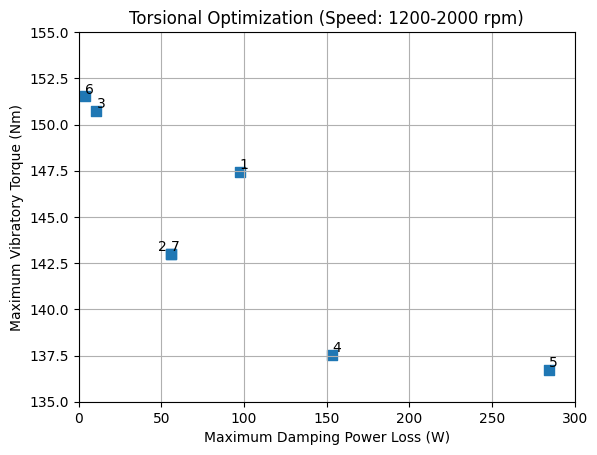

In [110]:
import matplotlib.pyplot as plt

plt.scatter(P_loss_max_ss, T_vib_max_ss, s=50, marker="s")

for i, (x, y) in enumerate(zip(P_loss_max_ss, T_vib_max_ss )):
    if i == 1:
        x = x-8
    plt.text(x, y, str(i + 1), fontsize=10, ha='left', va='bottom')
plt.grid(True)
plt.xlabel("Maximum Damping Power Loss (W)")
plt.ylabel("Maximum Vibratory Torque (Nm)")
plt.title("Torsional Optimization (Speed: 1200-2000 rpm)")
plt.xlim((0, 300))
plt.ylim((135, 155))
plt.show()

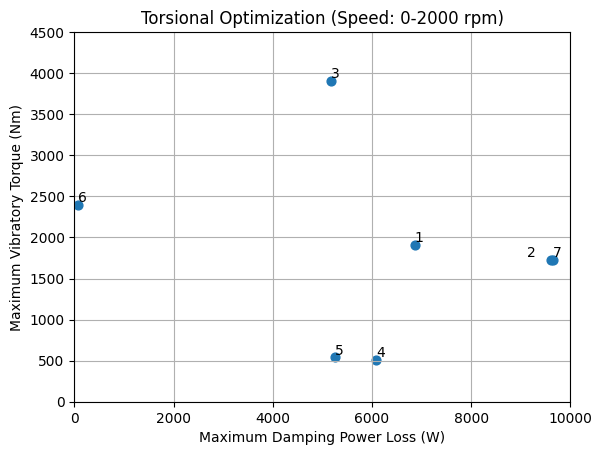

In [107]:
import matplotlib.pyplot as plt

plt.scatter(P_loss_max, T_vib_max, s=40, marker='o')

for i, (x, y) in enumerate(zip(P_loss_max, T_vib_max)):
    if i == 1:
        x = x-500
    plt.text(x, y, str(i + 1), fontsize=10, ha='left', va='bottom')
plt.grid(True)
plt.xlabel("Maximum Damping Power Loss (W)")
plt.ylabel("Maximum Vibratory Torque (Nm)")
plt.title("Torsional Optimization (Speed: 0-2000 rpm)")
plt.xlim((0, 10000))
plt.ylim((0, 4500))
plt.show()

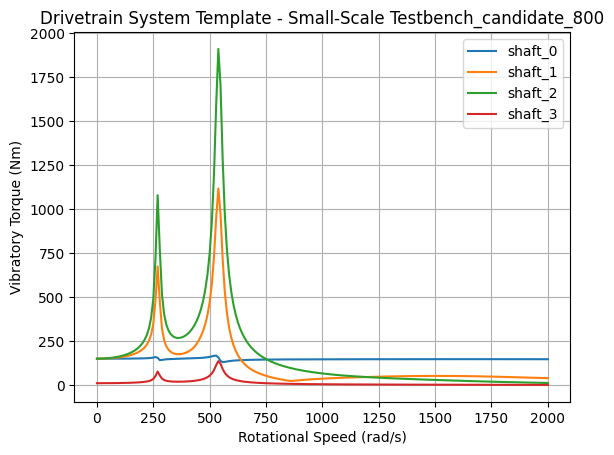

In [85]:
best_system = optimizer.final_results[0]
name = best_system["candidate"]
x = best_system["results"]["speeds_rad_s"] 
factor = 30 / 3.14
x = [v * factor for v in x]
t_vibs = best_system["results"]["vibratory_torque_Nm"]

for key, value in t_vibs.items():
    plt.plot(x, value, label=key)

plt.xlabel("Rotational Speed (rad/s)")
plt.ylabel("Vibratory Torque (Nm)")
plt.title(f"{name}")
plt.grid()
plt.legend()
plt.show()
